# 직원 이탈 예측하기 

In [141]:
# 1. 라이브러리 임포트
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [142]:
# 2. 파일 불러오기
churn_df = pd.read_csv('C:/juehyeon/aice_test/materials/datasets/employee_churn.csv')

In [143]:
## 파일 확인하기
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   years_experience   1056 non-null   float64
 1   salary             1056 non-null   float64
 2   education_level    1100 non-null   object 
 3   department         1100 non-null   object 
 4   overtime           1100 non-null   object 
 5   job_satisfaction   1100 non-null   int64  
 6   work_life_balance  1100 non-null   int64  
 7   attrition          1100 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 68.9+ KB


In [144]:
## 확인 결과 : years_experience, salary에 결측치 44개씩 존재함.

In [145]:
churn_df.head()

,years_experience,salary,education_level,department,overtime,job_satisfaction,work_life_balance,attrition
0,15.0,54.6,master,finance,N,3,4,1
1,5.6,116.6,bachelor,hr,N,3,2,1
2,11.0,32.2,phd,hr,N,4,2,1
3,16.2,82.2,phd,sales,Y,1,3,1
4,12.4,97.7,high_school,engineering,N,2,3,1


In [146]:
## 확인 결과 : education_level, department, overtime -> 범주형, 나머지는 수치형 변수 

<Axes: xlabel='department', ylabel='work_life_balance'>

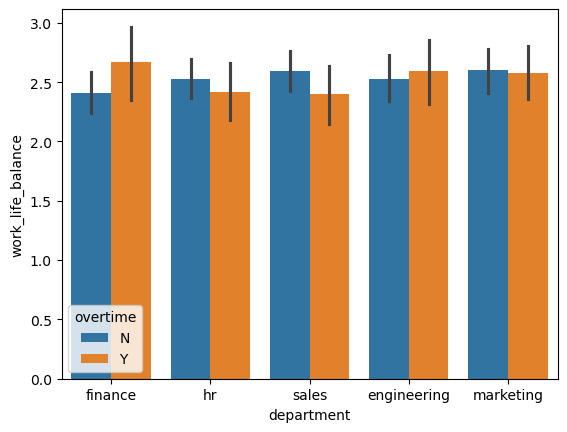

In [147]:
# 3. 데이터 시각화하기 -> work_life_balance(일과 삶의 균형 만족도)와 department(부서명)에 따른 overtime(초과근무)
## barplot 사용하기
sns.barplot(data = churn_df, x = 'department', y = 'work_life_balance', hue = 'overtime')

## 올바른 해석 고르기
1. 모든 부서에서 초과근무를 하지 않는 직원들의 일과  work_life_balance가 높다. (x)
2. finance 부서는 초과근무를 하는 직원의 work_life_balance가 더 높다. (o)
3. engineering 부서는 초과근무 여부와 관계없이 work_life_balance에 큰 차이가 없다. (x)
4. sales 부서는 초과근무를 하는 직원의 work_life_balance가 더 높다. (x)

In [148]:
답03 = 2

In [149]:
# 4. 결측치 처리하기
## 결측치 있는 컬럼 찾기 
churn_df.isnull().sum() # years_experience, salary에 결측치 44 존재

years_experience     44
salary               44
education_level       0
department            0
overtime              0
job_satisfaction      0
work_life_balance     0
attrition             0
dtype: int64

In [150]:
답04 = 'years_experience, salary'

In [151]:
## 결측치있는 행 삭제
pre_df = churn_df.dropna(axis = 0)

In [152]:
## 결측치 삭제 확인
pre_df.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 1014 entries, 0 to 1099
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   years_experience   1014 non-null   float64
 1   salary             1014 non-null   float64
 2   education_level    1014 non-null   object 
 3   department         1014 non-null   object 
 4   overtime           1014 non-null   object 
 5   job_satisfaction   1014 non-null   int64  
 6   work_life_balance  1014 non-null   int64  
 7   attrition          1014 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 71.3+ KB


In [153]:
## 인덱스 재정렬
pre_df = pre_df.reset_index(drop = True)

In [154]:
# 5. 데이터 분석 -> 직원들의 직무 만족도 평균 분석하여 높은 부서 찾기
## groupby로 데이터 정렬
temp = pre_df.groupby('department')['job_satisfaction'].mean()
temp

department
engineering    2.487047
finance        2.558252
hr             2.563877
marketing      2.600000
sales          2.505051
Name: job_satisfaction, dtype: float64

In [155]:
## 데이터 분석
답05 = 'marketing'

In [156]:
# 6. 데이터 분석 -> 부서별 이직 여부 비율 계산하기
## crosstab() 사용하여 비율 계산
pd.crosstab(index = pre_df['department'], columns = pre_df['attrition'], normalize = 'index')
print(pd.crosstab(index = pre_df['department'], columns = pre_df['attrition'], normalize = 'index').round(2))

attrition       0     1
department             
engineering  0.61  0.39
finance      0.67  0.33
hr           0.66  0.34
marketing    0.69  0.31
sales        0.73  0.27


In [157]:
## 가장 이직여부가 높은 부서 찾기
답06 = 'engineering'

In [158]:
# 7. 범주형 변수 인코딩
## 원핫 인코딩
encoding_df = pd.get_dummies(data = pre_df, columns = ['department'], drop_first = True)

In [159]:
encoding_df 

,years_experience,salary,education_level,overtime,job_satisfaction,work_life_balance,attrition,department_finance,department_hr,department_marketing,department_sales
0,15.0,54.6,master,N,3,4,1,True,False,False,False
1,5.6,116.6,bachelor,N,3,2,1,False,True,False,False
2,11.0,32.2,phd,N,4,2,1,False,True,False,False
3,16.2,82.2,phd,Y,1,3,1,False,False,False,True
4,12.4,97.7,high_school,N,2,3,1,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
1009,19.2,113.5,bachelor,N,1,1,1,False,False,False,False
1010,11.6,117.4,high_school,Y,2,2,0,False,True,False,False
1011,18.0,58.3,high_school,N,2,4,0,False,False,True,False
1012,15.9,39.8,master,Y,3,3,0,True,False,False,False


In [160]:
## map으로 인코딩
edu_map = {
    'high_school' : 0,
    'bachelor' : 1, 
    'master' : 2,
    'phd' : 3
}
encoding_df['education_level'] = encoding_df['education_level'].map(edu_map)

In [161]:
encoding_df

,years_experience,salary,education_level,overtime,job_satisfaction,work_life_balance,attrition,department_finance,department_hr,department_marketing,department_sales
0,15.0,54.6,2,N,3,4,1,True,False,False,False
1,5.6,116.6,1,N,3,2,1,False,True,False,False
2,11.0,32.2,3,N,4,2,1,False,True,False,False
3,16.2,82.2,3,Y,1,3,1,False,False,False,True
4,12.4,97.7,0,N,2,3,1,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
1009,19.2,113.5,1,N,1,1,1,False,False,False,False
1010,11.6,117.4,0,Y,2,2,0,False,True,False,False
1011,18.0,58.3,0,N,2,4,0,False,False,True,False
1012,15.9,39.8,2,Y,3,3,0,True,False,False,False


In [162]:
## np.where로 인코딩하기 -> Y:1, N:0
encoding_df['overtime'] = np.where(encoding_df['overtime'] == 'Y', 1, 0)

In [163]:
encoding_df

,years_experience,salary,education_level,overtime,job_satisfaction,work_life_balance,attrition,department_finance,department_hr,department_marketing,department_sales
0,15.0,54.6,2,0,3,4,1,True,False,False,False
1,5.6,116.6,1,0,3,2,1,False,True,False,False
2,11.0,32.2,3,0,4,2,1,False,True,False,False
3,16.2,82.2,3,1,1,3,1,False,False,False,True
4,12.4,97.7,0,0,2,3,1,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
1009,19.2,113.5,1,0,1,1,1,False,False,False,False
1010,11.6,117.4,0,1,2,2,0,False,True,False,False
1011,18.0,58.3,0,0,2,4,0,False,False,True,False
1012,15.9,39.8,2,1,3,3,0,True,False,False,False


In [164]:
# 8. 데이터 분리
## 입력값, 예측값 분리 
X = encoding_df.drop(columns = 'attrition')
y = encoding_df['attrition']

In [165]:
# 9. 훈련, 검증용 데이터 분리
## 라이브러리 임포트
from sklearn.model_selection import train_test_split

In [166]:
## 훈련, 검증 데이터셋 분리
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state = 42, test_size = 0.2)

In [167]:
# 10. 데이터 스케일링
## 라이브러리 임포트 
from sklearn.preprocessing import StandardScaler

In [168]:
## 모델 객체 생성
scaler = StandardScaler()
## 데이터 스케일링
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_valid)

In [169]:
# 11. 머신러닝 학습 - LightGBM 
## 모듈 설치 
!pip install lightgbm
## 라이브러리 임포트 
from lightgbm import LGBMClassifier

In [170]:
## 모델 객체 생성
lgbmc = LGBMClassifier(n_estimators = 100, max_depth = 6, learning_rate = 0.01, random_state = 10)

In [171]:
## 데이터 학습
lgbmc.fit(X_train, y_train) 

[LightGBM] [Info] Number of positive: 269, number of negative: 542
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000794 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 448
[LightGBM] [Info] Number of data points in the train set: 811, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.331689 -> initscore=-0.700555
[LightGBM] [Info] Start training from score -0.700555
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.01
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [172]:
# 12 머신러닝 학습 - XGBoost
## 라이브러리 임포트
from xgboost import XGBClassifier

In [173]:
## 모델 객체 생성
xgbc = XGBClassifier(n_estimators = 100, learning_rate = 0.1, random_state = 10)

In [174]:
## 데이터 학습
xgbc.fit(X_train, y_train) 

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [175]:
# 13. 정확도 , f1 score 비교하기
## 라이브러리 임포트
from sklearn.metrics import accuracy_score, f1_score

In [176]:
## 데이터 예측
lgbmc_predict = lgbmc.predict(X_test)
xgbc_predict = xgbc.predict(X_test) 

In [177]:
## 정확도 추출
lgbmc_accuracy_score = accuracy_score(y_valid, lgbmc_predict)
print(f'LGBMClassifier accuracy : {lgbmc_accuracy_score}')
xgbc_accuracy_score = accuracy_score(y_valid, xgbc_predict)
print(f'XGBoost accuracy : {xgbc_accuracy_score}')

## f1_score 추출
lgbmc_f1_score = f1_score(y_valid, lgbmc_predict)
print(f'LGBMClassifier accuracy : {lgbmc_f1_score}')
xgbc_f1_score = f1_score(y_valid, lgbmc_predict)
print(f'XGBoost f1_score : {xgbc_f1_score}')

LGBMClassifier accuracy : 0.6748768472906403
XGBoost accuracy : 0.6108374384236454
LGBMClassifier accuracy : 0.029411764705882353
XGBoost f1_score : 0.029411764705882353


In [178]:
# 14. 딥러닝 학습
## 라이브러리 임포트
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
tf.random.set_seed(10)

In [179]:
y_train = to_categorical(y_train, num_classes = 2)
y_valid = to_categorical(y_train, num_classes = 2)

In [180]:
## 모델 객체 생성
dl_model = Sequential([
    Input(shape = (X_train.shape[1],)),
    Dense(64, activation = 'selu'),
    BatchNormalization(),
    Dense(32, activation = 'selu'),
    BatchNormalization(),
    Dense(16, activation = 'selu'),
    Dense(2, activation = 'softmax')
])

In [181]:
## 모델 컴파일
dl_model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

In [182]:
## 모델 학습하기 
dl_model.fit(
    X_train, y_train,
    epochs = 50, 
    batch_size = 32
)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5092 - loss: 0.8838
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6079 - loss: 0.6691
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6535 - loss: 0.6352
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6584 - loss: 0.6211
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6695 - loss: 0.6097
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6831 - loss: 0.6004
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6880 - loss: 0.5927
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6930 - loss: 0.5866
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6967 - loss: 0.5805
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7028 - loss: 0.5753
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7065 - loss: 0.5706
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7102 - lo